In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score

In [18]:
supermarket_dataset= pd.read_csv("supermarket.csv")

In [12]:
print("Columns in your CSV:", supermarket_dataset.columns)

print(supermarket_dataset.head())

Columns in your CSV: Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furn

In [30]:
df = supermarket_dataset.drop(columns=['Country', 'City'])


X = df.drop(columns=['Profit'])
y = df['Profit']

X_encoded = pd.get_dummies(X, columns=['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category'], drop_first=True)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, test_size=0.2, 
    random_state=42)

In [33]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 7. Make predictions
y_pred = model.predict(X_test)


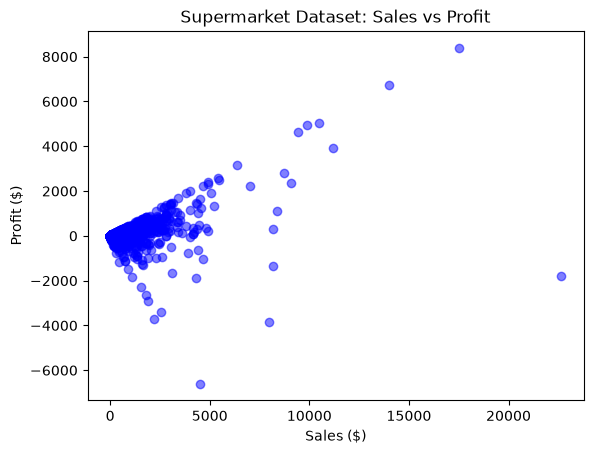

In [35]:
# Create a scatter plot of Sales vs Profit
plt.scatter(
    df['Sales'], 
    df['Profit'],
    alpha=0.5,      # Makes points semi-transparent to see overlapping data better
    color='blue'
)

plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.title("Supermarket Dataset: Sales vs Profit")

# Use plt.savefig('sales_vs_profit.png') if saving to a file, or plt.show() to view it
plt.show()